<a href="https://colab.research.google.com/github/obedglanson/senior_project_slc6a14/blob/main/split_AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 49.2 MB/s eta 0:00:00


Parsing 3D Ensembles and Computing Scaffolds...


[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerator
[20:27:46] DEPRECATION WARNING: please use MorganGenerat

Executing 5-Fold Bemis-Murcko Scaffold Split...

Fold 1:
Training: 545 conformers | Validation: 140 conformers

Fold 2:
Training: 545 conformers | Validation: 140 conformers

Fold 3:
Training: 550 conformers | Validation: 135 conformers

Fold 4:
Training: 550 conformers | Validation: 135 conformers

Fold 5:
Training: 550 conformers | Validation: 135 conformers

Mapping Chemical Space (PCA & t-SNE) for Representative Fold...
Saved Applicability_Domain_Fold1.png
All folds saved in 'CV_Folds' directory.


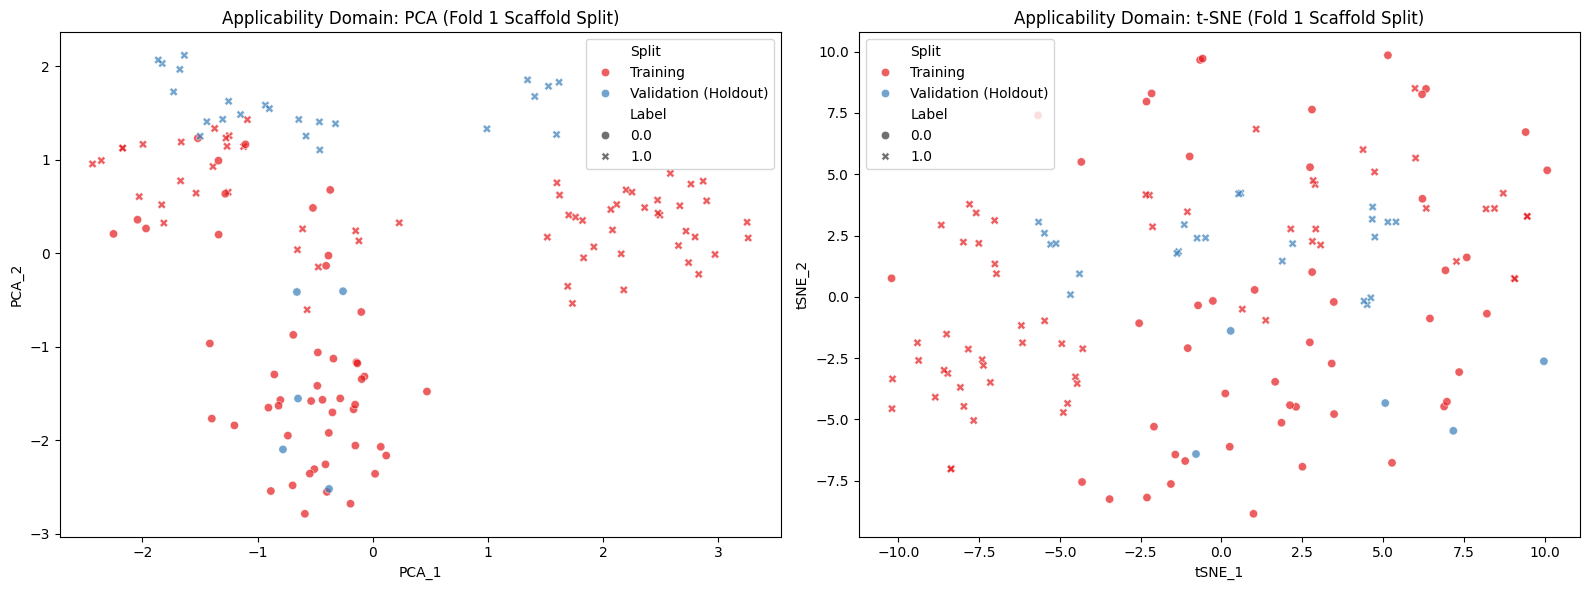

In [2]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def extract_scaffolds_and_features(sdf_path, label, dataset_name):
    """Parses SDF, calculates Murcko Scaffolds, and generates Morgan Fingerprints."""
    supplier = Chem.SDMolSupplier(sdf_path, removeHs=False)

    data = []
    for mol in supplier:
        if mol is None:
            continue

        parent_id = mol.GetProp("Parent_ID") if mol.HasProp("Parent_ID") else mol.GetProp("_Name")

        # Create a temporary 2D version to safely calculate topological features
        mol_2d = Chem.RemoveHs(mol)

        # 1. Bemis-Murcko Scaffold Calculation
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol_2d, includeChirality=False)

        # 2. Morgan Fingerprints (For AD)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol_2d, 2, nBits=2048)
        fp_array = np.zeros((0,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp, fp_array)

        data.append({
            'Parent_ID': parent_id,
            'Scaffold': scaffold,
            'Label': label,
            'Dataset': dataset_name,
            'Fingerprint': fp_array,
            'Mol_Object': mol # Keeps the 3D hydrogens and coordinates safe for export
        })

    return pd.DataFrame(data)

print("Parsing 3D Ensembles and Computing Scaffolds...")
df_actives = extract_scaffolds_and_features("Training_Actives_3D.sdf", label=1.0, dataset_name="Actives")
df_negatives = extract_scaffolds_and_features("Training_Negatives_3D.sdf", label=0.0, dataset_name="Negatives")
df_master = pd.concat([df_actives, df_negatives], ignore_index=True)

# 5-Fold Scaffold Splitting Bemis-Murcko
print("Executing 5-Fold Bemis-Murcko Scaffold Split...")
gkf = GroupKFold(n_splits=5)

# Output directory for the folds
os.makedirs("CV_Folds", exist_ok=True)

def write_split_to_sdf(df, filename):
    writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        writer.write(row['Mol_Object'])
    writer.close()

fold_num = 1
# Passing groups to prevent any positional matching bugs
for train_idx, val_idx in gkf.split(X=df_master, y=df_master['Label'], groups=df_master['Scaffold']):
    df_train = df_master.iloc[train_idx].copy()
    df_val = df_master.iloc[val_idx].copy()

    print(f"\nFold {fold_num}:")
    print(f"Training: {len(df_train)} conformers | Validation: {len(df_val)} conformers")

    # Export SDFs for this specific fold
    write_split_to_sdf(df_train[df_train['Label'] == 1.0], f"CV_Folds/Fold_{fold_num}_Train_Actives_3D.sdf")
    write_split_to_sdf(df_train[df_train['Label'] == 0.0], f"CV_Folds/Fold_{fold_num}_Train_Negatives_3D.sdf")
    write_split_to_sdf(df_val[df_val['Label'] == 1.0], f"CV_Folds/Fold_{fold_num}_Val_Actives_3D.sdf")
    write_split_to_sdf(df_val[df_val['Label'] == 0.0], f"CV_Folds/Fold_{fold_num}_Val_Negatives_3D.sdf")

    # Capture Fold 1 data for a single-fold representative plot
    if fold_num == 1:
        df_train['Split'] = 'Training'
        df_val['Split'] = 'Validation (Holdout)'
        df_mapped_fold1 = pd.concat([df_train, df_val], ignore_index=True)

    fold_num += 1


# Applicability Domain Mapping

print("\nMapping Chemical Space (PCA & t-SNE) for Representative Fold...")

# Deduplicate by Parent_ID so it doesnt plot 5 overlapping 2D points per 3D molecule
df_plot = df_mapped_fold1.drop_duplicates(subset=['Parent_ID']).copy()

X_embeddings = np.stack(df_plot['Fingerprint'].values)

# PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_embeddings)
df_plot['PCA_1'] = pca_results[:, 0]
df_plot['PCA_2'] = pca_results[:, 1]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X_embeddings)
df_plot['tSNE_1'] = tsne_results[:, 0]
df_plot['tSNE_2'] = tsne_results[:, 1]

# Plotting Configuration
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA Plot
sns.scatterplot(x='PCA_1', y='PCA_2', hue='Split', style='Label',
                palette='Set1', data=df_plot, ax=axes[0], alpha=0.7)
axes[0].set_title('Applicability Domain: PCA (Fold 1 Scaffold Split)')

# t-SNE Plot
sns.scatterplot(x='tSNE_1', y='tSNE_2', hue='Split', style='Label',
                palette='Set1', data=df_plot, ax=axes[1], alpha=0.7)
axes[1].set_title('Applicability Domain: t-SNE (Fold 1 Scaffold Split)')

plt.tight_layout()
plt.savefig("Applicability_Domain_Fold1.png", dpi=300)
print("Saved Applicability_Domain_Fold1.png")
print("All folds saved in 'CV_Folds' directory.")